In [1]:
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

import lib.sims as sims
import lib.utils as utils

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.formula.api as smf
from collections import Counter
from tqdm.notebook import trange, tqdm
import warnings
from scipy.stats import gamma, truncnorm

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

DARK, GGPLOT, DEFAULT = 'dark_background', 'ggplot', 'default'

# Fit learning curves

,pid,condition,famInd,correct,ones,familyTrialsComplete
0,55d6e23469dbc30010b66dc3,free,4,0,1,1
1,55d6e23469dbc30010b66dc3,free,1,0,1,1
2,55d6e23469dbc30010b66dc3,free,3,0,1,1
3,55d6e23469dbc30010b66dc3,free,4,1,1,2
4,55d6e23469dbc30010b66dc3,free,1,0,1,2
...,...,...,...,...,...,...
107038,64011d89460937cf59669000,interleaved,3,0,1,59
107039,64011d89460937cf59669000,interleaved,4,1,1,59
107040,64011d89460937cf59669000,interleaved,4,1,1,60
107041,64011d89460937cf59669000,interleaved,1,0,1,60


Optimization terminated successfully.
         Current function value: 0.628898
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.632080
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.584288
         Iterations 5


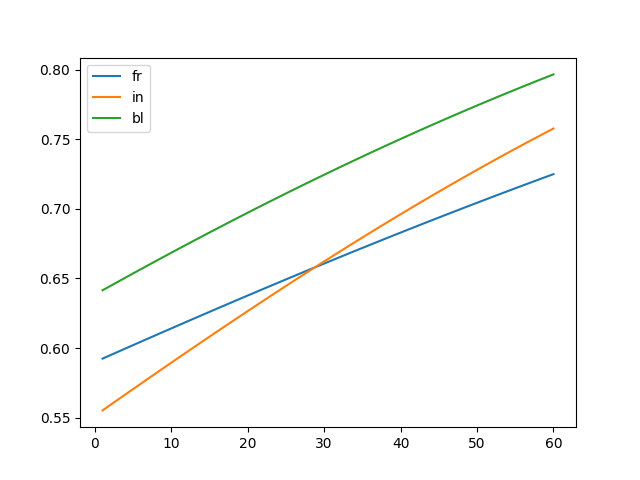

In [3]:
df = pd.read_csv('data/Mar2023/combined_filtered.csv')
df = df.query('stage == "epochs"')
df = df.filter(items=['pid', 'condition', 'famInd', 'correct'])
df = df.assign(correct = df.correct.astype(int), ones = 1)
df = df.assign(familyTrialsComplete = df.groupby(['pid', 'famInd']).ones.cumsum())

display(df)

models = {}
for group in ['free', 'interleaved', 'blocked']:
    models[group[:2]] = smf.logit('correct ~ familyTrialsComplete', data=df.query('condition == @group')).fit()

fig, ax = plt.subplots()

x = np.linspace(1, 60)
for i, (label, model) in enumerate(models.items()):
    y = model.predict(exog=dict(familyTrialsComplete = x))
    ax.plot(x, y, label=label)

ax.legend()

# Parameter recovery for logistic regression

  0%|          | 0/500 [00:00<?, ?it/s]

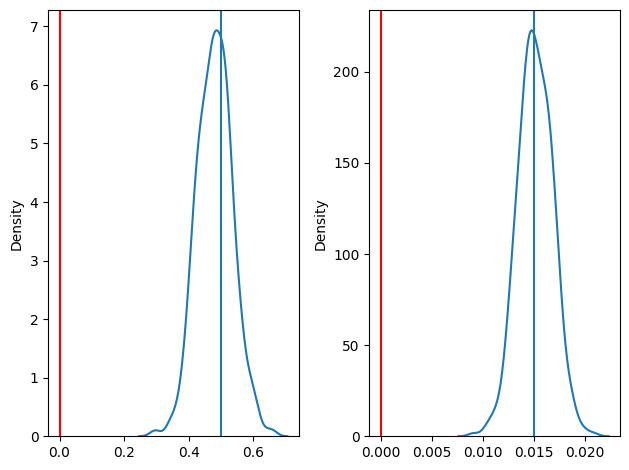

In [168]:
# True parameters
b0 = 0.5
b1  =.015

recov = []

# Simulate data
for i in tqdm(range(500)):
    simdf = gen_ind_data(60, b0=b0, b1=b1, n_subjects=100)

    # Recover data
    m = smf.logit('o ~ 1 + t', data=simdf).fit(disp=0)
    recov.append(m.params)
    # print(f'b0 = {m.params[0]}; b1 = {m.params[1]}')

recov = np.stack(recov, axis=0)

# Plot simulated recover runs
fig, ax = plt.subplots(ncols=2)

for i, param in enumerate([b0, b1]):
    sns.kdeplot(x=recov[:, i], ax=ax[i])
    ax[i].axvline(param)
    ax[i].axvline(0, color='red')

fig.tight_layout()

# Demos

## Assumptions

1. Choice is stochastic (softmax function with temperature parameter)
2. Choice probability depends on utility (the utility part of the choice function)
3. Utility is a linear combination of latent factors (e.g., LP)
4. Probability of responding correctly is a sigmoidal function of time (idealized learning curve).
5. Learning curves are the same for all tasks
6. Learning curves are the same for all participants
7. LP is the partial derivative of the sigmoidal learning curve with respect to time


## One model

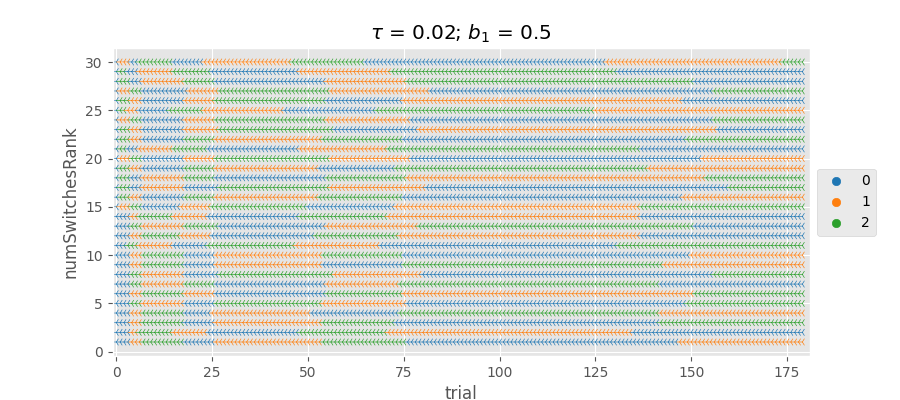

In [3]:
with plt.style.context('ggplot'):
    tau = .02
    b1 = 0.5
    choice_data, h_utility = sims.sim_choices(    
        # Setup
        T = 180, # Number of trials
        N = 30, # Number of subjects
        K = 3, # Number of tasks
        
        # Utility params
        tau = tau,

        # learning params
        b0 = 0.5,
        b1 = b1
    )

    N, T = choice_data.shape
    switch = np.insert((choice_data[:, 1:]!=choice_data[:, :-1]), 0, np.zeros(N), axis=1).flatten()
    choice_data_flat = choice_data.flatten()
    trials = np.tile(np.arange(T), N)
    pids = np.repeat(np.arange(N), T)

    df = pd.DataFrame(dict(pid=pids, trial=trials, choice=choice_data_flat, switch=switch))
    df = df.assign(numSwitches = df.groupby('pid').switch.transform(sum))
    ranks = df.groupby('pid')[['pid','numSwitches']].head(1).reset_index()
    ranks['numSwitchesRank'] = ranks.numSwitches.rank(method='first').astype(int)
    df = df.merge(ranks[['pid', 'numSwitchesRank']], how='outer', on='pid')
    df = df.sort_values(by=['numSwitchesRank'])

    fig, ax = plt.subplots(figsize=[9, 4])
    sns.scatterplot(
        data = df,
        x = 'trial', 
        y = 'numSwitchesRank', 
        hue = 'choice',
        marker = '3',
        palette= 'tab10',
        ax = ax
    )
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_xlim(-1, 181)
    ax.set_title(fr'$\tau$ = {tau}; $b_1$ = {b1}')
    # display(df)

# Effects

We can characterize each sequence of choices in terms of their randomness, the streak length variability, and the number of switches.

## Only random choices

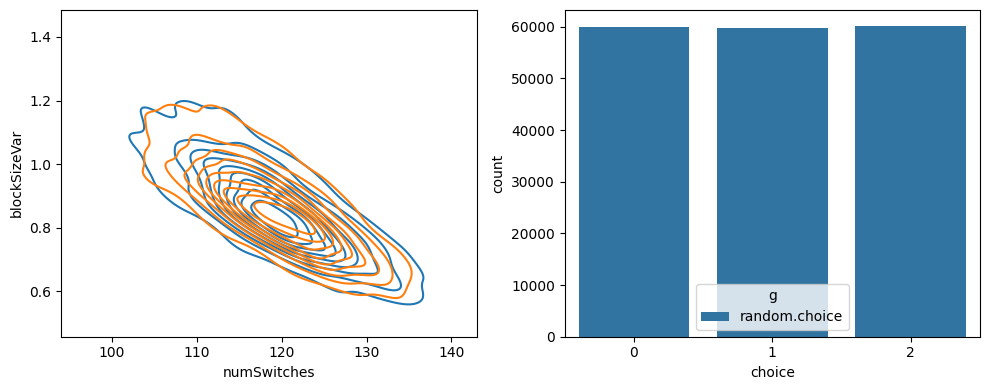

In [100]:
N, T = 1000, 180
random_color = 'blueviolet'
fig, ax = plt.subplots(figsize=[10, 4], ncols=2)

# Random data np.random.randint
# =====================================================
rand_data1 = np.random.randint(0, 3, N*T).reshape([N, T])
df1 = sims.as_df(rand_data1)
df1_ = df1.copy()
df1_ = df1_.assign(g = 'random.randint')
df1 = sims.summarize_choices(df1)
sns.kdeplot(x='numSwitches', y='blockSizeVar', fill=False, data=df1, ax=ax[0])

# Random data np.random.randint
# =====================================================
rand_data2 = np.stack([np.random.choice([0, 1, 2], T, p=[1/3, 1/3, 1/3]) for i in range(N)], axis=0)
df2 = sims.as_df(rand_data2)
df1_['g'] = 'random.choice'
sns.countplot(x='choice', data=pd.concat([df1_, df2], axis=0), hue='g', ax=ax[1])
df2 = sims.summarize_choices(df2)
sns.kdeplot(x='numSwitches', y='blockSizeVar', fill=False, data=df2, ax=ax[0])


fig.tight_layout()

# Interactive simulation: N subjects

interactive(children=(FloatText(value=0.0001, description='τ', step=0.0005), FloatText(value=0.0, description=…

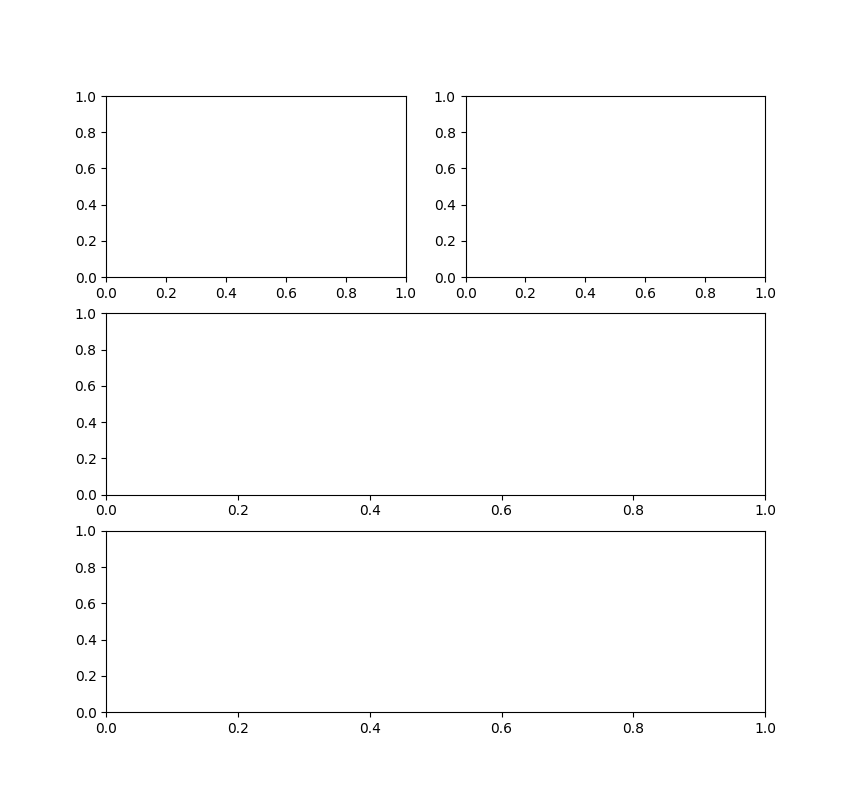

In [6]:
N, T = 100, 180
plt.close()
fig = plt.figure(num='Interactive simulations', figsize=[8.5, 8])
gs = gridspec.GridSpec(3, 2)

class MyAxisGrid(object):
    def __init__(self):
        self.scatter = plt.subplot(gs[0, 0])
        self.entropy = plt.subplot(gs[0, 1])
        self.switching = plt.subplot(gs[1, :])
        self.lcurve = None #plt.subplot(gs[1, 1])
        self.choices = plt.subplot(gs[2, :])

    def clear(self):
        for ax in self.__dict__.values():
            if ax is not None:
                ax.clear()


# Random data
rand_color = 'gray'
rand_data = np.random.randint(0, 3, N*T).reshape([N, T])

# Human data
human_color = 'salmon'
df = pd.read_csv('data/Mar2023/combined_filtered.csv', usecols=['pid', 'stage', 'condition', 'trialsComplete', 'famInd'])
df = df.query('condition == "free" and stage == "epochs"')
assert all(df.groupby('pid').trialsComplete.count() == 180)
human_data = df.famInd.values.reshape([-1, 180]) - 2
human_data[human_data < 0] = 0

model_color = 'royalblue'
def int_sim(tau, b0, b1, wlp, wpc, wnov, wrb, humans, fixed_dict):
    ax = fixed_dict['ax']
    ax.clear()

    # Random data
    sims.plot_choice_data(fixed_dict['rand_data'], ax, rand_color)

    # Optional human data
    if humans:
        sims.plot_choice_data(fixed_dict['human_data'], ax, human_color)

    # Model-simulated data
    choice_data, h_utility = sims.sim_choices(    
        T = 180, # Number of trials
        N = 50, # Number of subjects
        K = 3, # Number of tasks
        tau = tau,
        b0 = b0,
        b1 = b1,
        wlp = wlp,
        wpc = wpc,
        wnov = wnov,
        wrb = wrb
    )
    sims.plot_choice_data(choice_data, ax, color=model_color)
    # sims.plot_util(T, b0, b1, wlp, wnov, wrb, ax.lcurve)

    # Format labels
    sims.format_labels(ax)

fixed_dict = dict(
    ax = MyAxisGrid(),
    rand_data = rand_data,
    human_data = human_data

)

tau  = widgets.FloatText(value=0.0001, description='τ', step=.0005)
b0   = widgets.FloatText(value=0.0, description='b<sub>0</sub>')
b1   = widgets.FloatText(value=0.015, description='b<sub>1</sub>', step=0.005)
wlp  = widgets.FloatText(value=0, description='w<sub>LP</sub>', step=10)
wpc  = widgets.FloatText(value=0, description='w<sub>PC</sub>', step=10)
wnov = widgets.FloatText(value=0.015, description='w<sub>Nov</sub>', step=.0001)
wrb  = widgets.FloatText(value=.5, description='w<sub>RB</sub>', step=.1)
nu   = widgets.FloatText(value=180, min=5, max=180, description='nu', step=1)
humans = widgets.ToggleButton(value=False, description='Human data', tooltip='Toggle human data')
interactive_plot = interact_manual(int_sim,
    tau = tau,
    b0 = b0,
    b1 = b1,
    wlp = wlp,
    wpc = wpc,
    wnov = wnov,
    wrb = wrb,
    humans = humans,
    fixed_dict = fixed(fixed_dict),
    continuous_update = False
)

# Interactive simulation: 1 subject

interactive(children=(IntSlider(value=5, description='trial', max=180, min=5), Output()), _dom_classes=('widge…

Output()

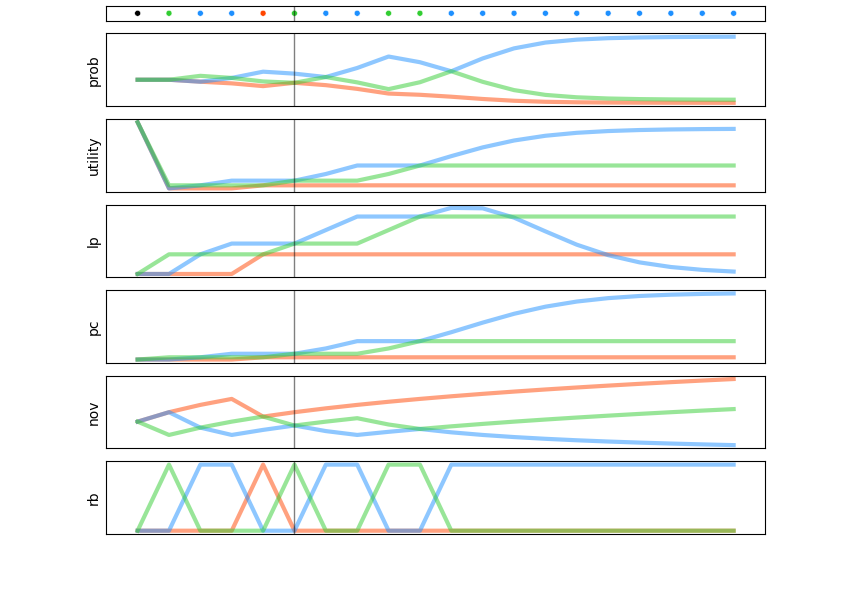

In [4]:
plt.close()
fig, ax = plt.subplots(num='Interactive simulation: 1 subject', nrows=7, height_ratios=[1,5,5,5,5,5,5], figsize=[8.5, 6], sharex=True)
fig.subplots_adjust(top=.99)
colors = ['orangered', 'dodgerblue', 'limegreen', 'black']
linestyles = ['solid', (0, (5, 2)), (0, (1, 1))]
vlines = []

def sim_one(n, tau, b0, b1, wlp, wpc, wnov, wrb, nu):
    c, hist = sims.sim_choices(1, n, 3, tau=tau, b0=b0, b1=b1, wlp=wlp, wpc=wpc, wnov=wnov, wrb=wrb, nu=nu)
    
    ax[0].clear()
    ax[0].set_xlim([-1, n])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        hue = c[0, :].squeeze()
        hue[0] = 3
        sns.scatterplot(x=np.arange(n), y=np.zeros(n), hue=hue, palette=dict(zip(range(4), colors)), size=1, ax=ax[0])
    ax[0].legend().remove()
    ax[0].set_yticklabels([])
    ax[0].set_yticks([])
    for i, k in enumerate(['prob', 'utility','lp', 'pc','nov','rb']):
        ax[i+1].clear()
        ax[i+1].set_ylabel(k)
        for j in range(3):
            ax[i+1].plot(hist[k][:, j], alpha=.5, lw=3, color=colors[j])

    for a in ax:
        if a != ax[-1]:
            a.set_xticklabels([])
            a.set_xticks([])
        a.set_yticklabels([])
        a.set_yticks([])


def move_pointer(t):
    while vlines:
        vlines.pop().remove()
    
    for a in ax:
        vlines.append(a.axvline(t, lw=1, alpha=.5, color='k'))


# Interactivity
# =================================================================
n    = widgets.IntSlider(value=20, min=5, max=180, description='N<sub>trials</sub>')
t    = widgets.IntSlider(value=0, min=5, max=180, description='trial')
tau  = widgets.FloatText(value=0.2, description='τ', step=.02)
b0   = widgets.FloatText(value=-3.0, description='b<sub>0</sub>')
b1   = widgets.FloatText(value=0.55, description='b<sub>1</sub>', step=0.05)
wlp  = widgets.FloatText(value=1.0, description='w<sub>LP</sub>', step=1)
wpc  = widgets.FloatText(value=1.0, description='w<sub>PC</sub>', step=1)
wnov = widgets.FloatText(value=0.0, description='w<sub>Nov</sub>', step=.1)
wrb  = widgets.FloatText(value=0.0, description='w<sub>RB</sub>', step=.1)
nu   = widgets.FloatText(value=180, min=5, max=180, description='nu', step=1)

col1 = widgets.VBox([n, tau, b0, b1, nu])
col2 = widgets.VBox([wlp, wpc, wnov, wrb])
ui = widgets.HBox([col1, col2])

out = widgets.interactive_output(sim_one, dict(n=n, tau=tau,b0=b0,b1=b1,wlp=wlp,wpc=wpc,wnov=wnov,wrb=wrb,nu=nu))

display(interactive(move_pointer, t=t))
display(ui, out)


# Simulation: N subjects (individual differences)

tau = 0.340
b0 = -4.504
b1 = 0.265
wlp = 11.692
wpc = 1.531
wnov = 0.000
wrb = 0.000


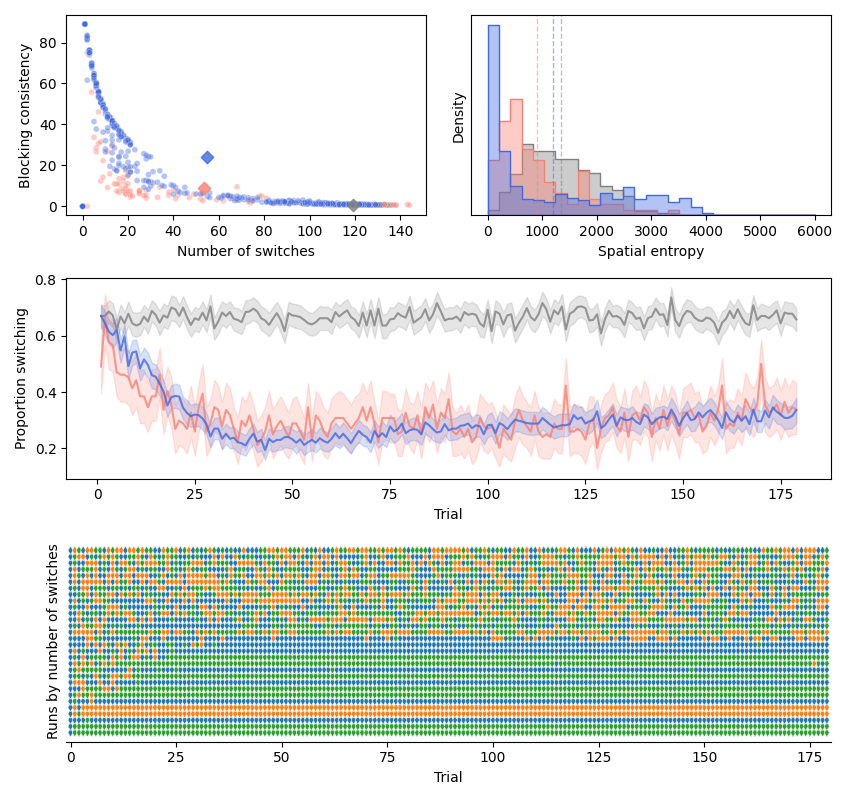

In [5]:
N, T = 500, 180
plt.close()
fig = plt.figure(num='Interactive simulations (ind. diffs)', figsize=[8.5, 8])
gs = gridspec.GridSpec(3, 2)

class MyAxisGrid(object):
    def __init__(self):
        self.scatter = plt.subplot(gs[0, 0])
        self.entropy = plt.subplot(gs[0, 1])
        self.switching = plt.subplot(gs[1, :])
        self.lcurve = None #plt.subplot(gs[1, 1])
        self.choices = plt.subplot(gs[2, :])

    def clear(self):
        for ax in self.__dict__.values():
            if ax is not None:
                ax.clear()

ax = MyAxisGrid()

# Random data
rand_color = 'gray'
rand_data = np.random.randint(0, 3, N*T).reshape([N, T])
sims.plot_choice_data(rand_data, ax, rand_color)

# Human data
human_color = 'salmon'
df = pd.read_csv('data/Mar2023/combined_filtered.csv', usecols=['pid', 'stage', 'condition', 'trialsComplete', 'famInd'])
df = df.query('condition == "free" and stage == "epochs"')
assert all(df.groupby('pid').trialsComplete.count() == 180)
human_data = df.famInd.values.reshape([-1, 180]) - 2
human_data[human_data < 0] = 0
sims.plot_choice_data(human_data, ax, human_color)

N = 500
tau  = gamma.rvs(a=1.2, scale=.3, size=N)
b0   = np.random.uniform(-6.00, -3.00, N)
b1   = truncnorm.rvs(0, 1000, loc=0.2, scale=0.08, size=N)
wlp  = gamma.rvs(a=12, scale=0.99, size=N)
wpc  = gamma.rvs(a=2, scale=0.80, size=N)
# b0 = np.ones(N) * -.4
# b1   = np.random.uniform(0.3, 0.02, N)
# wlp  = np.random.normal(0.0, 5, size=N)
# wpc  = np.random.normal(0.0, 4, size=N)
wnov = gamma.rvs(a=3.50, scale=1.3, size=N) * 0
wrb  = gamma.rvs(a=3.75, scale=1.5, size=N) * 0

params = {"tau":tau, "b0":b0, "b1":b1, "wlp":wlp, "wpc":wpc, "wnov":wnov, "wrb":wrb}
for k, v in params.items():
    print(f"{k} = {np.mean(v):.3f}")

sim_data = []
for i in range(N):
    # Model-simulated data
    choice_data, h_utility = sims.sim_choices(    
        N = 1, # Number of subjects
        T = 180, # Number of trials
        K = 3, # Number of tasks
        tau = tau[i],
        b0 = b0[i],
        b1 = b1[i],
        wlp = wlp[i],
        wpc = wpc[i],
        wnov = wnov[i],
        wrb = wrb[i]
    )
    sim_data.append(choice_data)

sim_data = np.stack(sim_data, axis=0).squeeze()
model_color = 'royalblue'
sims.plot_choice_data(sim_data, ax, color=model_color)

# Format labels
sims.format_labels(ax)

# Gamma distribution

interactive(children=(FloatText(value=0.1, description='alpha', step=0.02), FloatText(value=0.1, description='…

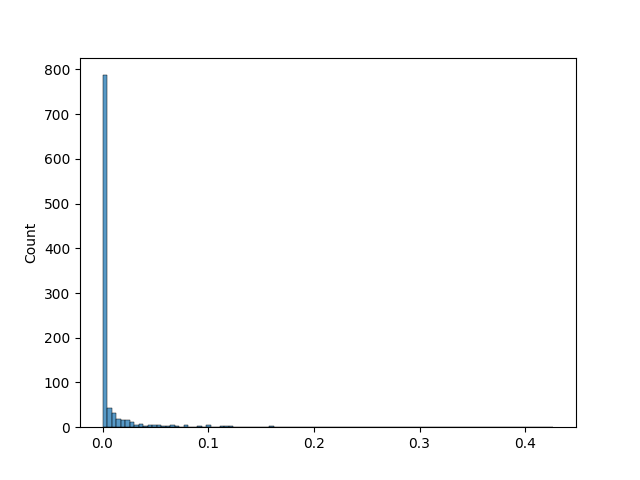

In [171]:
plt.close()
fig, ax = plt.subplots(num='Gamma')

def g(a, scale, N):
    print(a, scale)
    print(np.mean(gamma.rvs(a=a, scale=scale, size=N)))
    ax.clear()
    sns.histplot(y, bins=100, ax=ax)


# Interactivity
# =================================================================
a    = widgets.FloatText(value=0.1, min=0, max=2, step=.02, description="alpha")
scale  = widgets.FloatText(value=0.1, min=0, max=2, step=.02, description='scale')

out = widgets.interact(g, a=a, scale=scale, N=fixed(1000))


In [86]:
y = gamma.rvs(a=0.1, scale=0.1, size=1000)
print(np.mean(y), y.size)

0.008897767625127 1000
